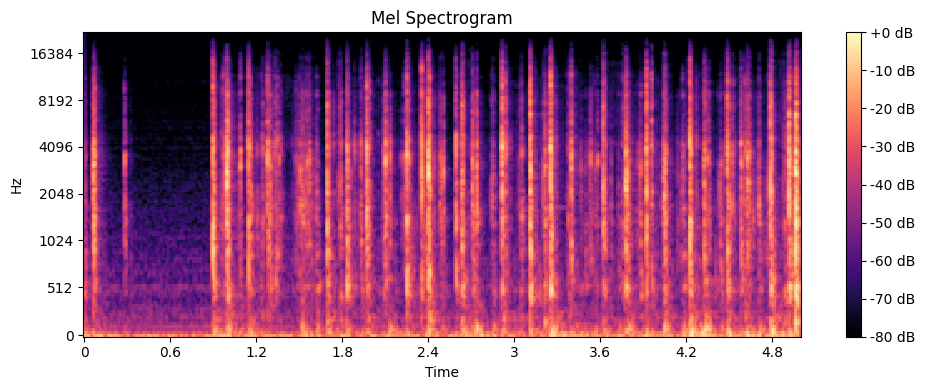

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Percorso a un file audio WAV
file_path = '/Users/giovannilonia/Downloads/Sound-Recognition/Datasets/ESC50/audio/audio/1-137-A-32.wav'  # Cambia con il tuo percorso

# Carica l'audio
y, sr = librosa.load(file_path, sr=None)

# Estrai spettrogramma di Mel
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_DB = librosa.power_to_db(S, ref=np.max)

# Visualizza
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_DB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.tight_layout()
plt.show()


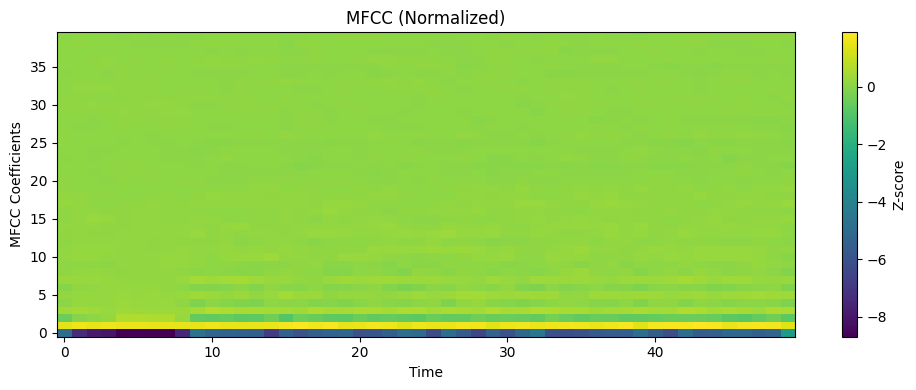

In [2]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize

def extract_mfcc(file_path, n_mfcc=40, target_shape=(40, 50)):
    """Extract and resize MFCC features from a WAV file."""
    y, sr = librosa.load(file_path, sr=44100)  # fixed 44.1kHz
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # Resize to fixed size (e.g., 40 x 50)
    mfcc_resized = resize(mfcc, target_shape, mode='constant', anti_aliasing=True)

    # Normalize (per-sample z-score)
    mfcc_normalized = (mfcc_resized - mfcc_resized.mean()) / (mfcc_resized.std() + 1e-9)

    return mfcc_normalized  # shape: (40, 50)

# --- Example usage ---
#file_path = 'your_audio.wav'  # replace with your actual WAV file path
mfcc_features = extract_mfcc(file_path)

# --- Plotting ---
plt.figure(figsize=(10, 4))
plt.imshow(mfcc_features, aspect='auto', origin='lower', cmap='viridis')
plt.title('MFCC (Normalized)')
plt.xlabel('Time')
plt.ylabel('MFCC Coefficients')
plt.colorbar(label='Z-score')
plt.tight_layout()
plt.show()
